In [2]:
# Runtime cell (once per session)
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ==============================================
# Cell 0 — load/rename/duplicate audit/drop treatment-missing
# ==============================================
import numpy as np, pandas as pd
import pytensor
from pytensor import tensor as pt
import pymc as pm, arviz as az

print("NumPy:", np.__version__)
print("PyMC:", pm.__version__)
print("PyTensor:", pytensor.__version__)
print("ArviZ:", az.__version__)

import pandas.api.types as ptypes
# --- Load ---
data_file = "/content/drive/MyDrive/CIF/cifs2037.csv"
df = pd.read_csv(
    data_file,
    header=0,
    na_values=["NA", 99, -99],
    keep_default_na=True
)

# ==============================================
# Duplicate audit & (optional) resolution on idnumber
# ==============================================
# Place this right after you read the CSV, before renaming/dropping cols.

# 0) Standardize ID text form to be safe
if 'idnumber' not in df.columns:
    raise KeyError("Column 'idnumber' not found. Check the CSV header.")
df['idnumber'] = df['idnumber'].astype(str).str.strip()

N0 = len(df)

# 1) TRUE ROW duplicates (identical across all columns)
true_dups_mask = df.duplicated(keep=False)  # same content, any column
true_dups = df.loc[true_dups_mask].copy()
n_true_groups = true_dups.duplicated().sum()  # count removed if we kept first
print(f"True row duplicates (identical rows): {true_dups.shape[0]} rows (would remove {n_true_groups} if dropped).")

# 2) ID collisions (same idnumber, possibly different content)
id_dups_mask = df.duplicated(subset=['idnumber'], keep=False)
id_dups = df.loc[id_dups_mask].sort_values(['idnumber']).copy()
n_ids_with_dups = id_dups['idnumber'].nunique()
print(f"IDs with >1 row (ID collisions): {n_ids_with_dups} unique IDs")

# 3) Quick context for collisions: years per ID (if present)
if 'year' in df.columns:
    years_per_id = (id_dups.groupby('idnumber')['year']
                    .agg(lambda s: sorted(pd.to_numeric(s, errors='coerce').dropna().unique().tolist())))
    print("Example duplicated IDs with their years:\n", years_per_id.head(10))

# 4) Save audit for manual review
id_dups.to_csv("duplicate_id_rows_full.csv", index=False)
true_dups.to_csv("duplicate_true_rows_full.csv", index=False)
print("Saved duplicate audit files: duplicate_id_rows_full.csv, duplicate_true_rows_full.csv")

# 5) (Optional) Remove exact row duplicates ONLY (safe)
df_noduprows = df.drop_duplicates().copy()
print(f"After dropping exact duplicate rows: {len(df_noduprows)} / {N0}")

# 6) (Optional) Enforce one row per child (choose 'best' row per ID)
#    Rule: keep the row with the MOST non-missing key covariates;
#    tie-breaker: prefer year==1, then earliest entry date.
#    You can switch this off by setting ENFORCE_ONE_ROW_PER_ID=False
ENFORCE_ONE_ROW_PER_ID = True

# Identify columns for scoring (use whatever exists at this stage)
ratio_col  = 'I_to_N_ratio' if 'I_to_N_ratio' in df_noduprows.columns else ('I-to-N ratio' if 'I-to-N ratio' in df_noduprows.columns else None)
treat_col  = 'FaInc' if 'FaInc' in df_noduprows.columns else ('PI' if 'PI' in df_noduprows.columns else None)
key_covs   = [c for c in ['program','gender','ethnic','AgeM', ratio_col, 'educat'] if c and c in df_noduprows.columns]
if treat_col:
    key_covs = [treat_col] + key_covs

# helper features for tie-breaks
df_noduprows['_key_nonmiss'] = df_noduprows[key_covs].notna().sum(axis=1)
if 'year' in df_noduprows.columns:
    df_noduprows['year_num'] = pd.to_numeric(df_noduprows['year'], errors='coerce')
    df_noduprows['_year_pref'] = (df_noduprows['year_num'] == 1).astype(int)
else:
    df_noduprows['_year_pref'] = 0

if 'entry' in df_noduprows.columns:
    df_noduprows['entry_dt'] = pd.to_datetime(df_noduprows['entry'], errors='coerce')
else:
    df_noduprows['entry_dt'] = pd.NaT

if ENFORCE_ONE_ROW_PER_ID:
    # sort to put the 'best' record first within each idnumber
    df_one = (df_noduprows
              .sort_values(['idnumber','_key_nonmiss','_year_pref','entry_dt'],
                           ascending=[True, False, False, True])
              .drop_duplicates(subset=['idnumber'], keep='first')
              .copy())
    print(f"Enforced one row per idnumber: {len(df_one)} rows (from {len(df_noduprows)})")
else:
    df_one = df_noduprows.copy()
    print("Kept multiple rows per idnumber (no consolidation).")

# 7) Keep an analysis-tracking ID if you don’t already have one
if 'orig_id' not in df_one.columns:
    df_one['orig_id'] = np.arange(len(df_one))

# 8) OPTIONAL: sanity report on how often the rule picks year==1
if 'year' in df_noduprows.columns and ENFORCE_ONE_ROW_PER_ID:
    picked = df_one.merge(df_noduprows[['idnumber','year_num','_key_nonmiss']], on=['idnumber'], how='left', suffixes=('','_all'))
    print("Among consolidated IDs, proportion with year==1 selected:",
          np.mean((picked['year_num'] == 1).fillna(False)))

# 9) Replace df with deduplicated version for the rest of the pipeline
df = df_one.drop(columns=['_key_nonmiss','_year_pref','entry_dt','year_num'], errors='ignore').copy()

# ================================
# Fix specific impossible 'program' values by ID
# ================================
import pandas.api.types as ptypes

# Ensure these columns exist
if 'idnumber' not in df.columns or 'program' not in df.columns:
    raise KeyError("Expected columns 'idnumber' and 'program' not found.")

# Normalize types for matching/assignment
id_as_str = df['idnumber'].astype(str).str.strip()
prog_was_categorical = ptypes.is_categorical_dtype(df['program'])

# Work on a numeric view of program (handles '1'/'2' strings or categories)
prog_num = pd.to_numeric(df['program'], errors='coerce')

# --- 1) Set program 2 -> 1 for idnumber = 259  (row.numberCIPS_2520 == 272 in your R notes)
mask_259 = (id_as_str == '259')
changed_259_before = prog_num.loc[mask_259].copy()
prog_num.loc[mask_259] = 1

# (Optional) if you also track by row.numberCIPS_2520, enforce it too
if 'row.numberCIPS_2520' in df.columns:
    mask_row = (pd.to_numeric(df['row.numberCIPS_2520'], errors='coerce') == 272)
    prog_num.loc[mask_row] = 1

# --- 2) Set program 1 -> 2 for the 8 specified IDs
ids_to_2 = ['811','854','987','1012','1018','1183','1186','1209']
mask_to2 = id_as_str.isin(ids_to_2)
changed_to2_before = prog_num.loc[mask_to2].copy()
prog_num.loc[mask_to2] = 2

# Write back and restore dtype if needed
df['program'] = prog_num.astype('Int64')
if prog_was_categorical:
    df['program'] = df['program'].astype('category')

# --- Reporting ---
print(f"Rows affected for id 259: {int(mask_259.sum())}")
print(f"Rows affected for ids {ids_to_2}: {int(mask_to2.sum())}")

# Quick verification table
check_ids = ['259'] + ids_to_2
print(df.loc[id_as_str.isin(check_ids), ['idnumber','program']].sort_values('idnumber').head(30))

# ================================
# Organization of the data
# ================================

# --- Track rows for later merges/QA ---
df['orig_id'] = np.arange(len(df))

# --- Rename columns you want standardized ---
rename_map = {
    'I-to-N ratio': 'I_to_N_ratio',  # hyphen → underscore
    'PI': 'FaInc'                    # treatment (father incarceration)
}
df = df.rename(columns=rename_map)

# --- Drop ONLY the variables you listed (ignore if any aren't present) ---
to_drop = [
    'idnumber', 'year', 'birth', 'entry', 'AGEM_O', 'PI', 'chilfam', 'adultfam',
    'Family size', 'income', 'Poverty threshold', 'caregiv', 'parincar'
]
present_to_drop = [c for c in to_drop if c in df.columns]
df = df.drop(columns=present_to_drop, errors='ignore')
print("Dropped columns:", present_to_drop)

# --- Keep all rows except those with missing FaInc (treatment) ---
if 'FaInc' not in df.columns:
    raise KeyError("FaInc not found. Make sure the source column 'PI' exists so it can be renamed to 'FaInc' earlier.")

before = len(df)
df = df.loc[df['FaInc'].notna()].copy()
print(f"Dropped {before - len(df)} rows due to missing FaInc; retained {len(df)}.")

# Ensure FaInc is a clean binary (0/1) nullable integer
df['FaInc'] = pd.to_numeric(df['FaInc'], errors='coerce').round()
df['FaInc'] = df['FaInc'].astype('Int64')

# --- Canonical typing rules ---
CATEGORICAL = ['FaInc', 'program', 'gender', 'ethnic']   # FaInc is categorical but NOT imputed
NUMERIC_COVS = ['AgeM', 'I_to_N_ratio', 'educat']        # note: 'educat' treated as numeric

# Propensity covariates (pre-treatment only)
COVS = ['program', 'gender', 'ethnic'] + NUMERIC_COVS

# --- Enforce dtypes safely ---
# FaInc: keep as nullable integer 0/1 (not imputed)
df['FaInc'] = pd.to_numeric(df['FaInc'], errors='coerce').round().astype('Int64')

# Categorical covariates (excluding FaInc)
for c in ['program', 'gender', 'ethnic']:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Numeric covariates
for c in NUMERIC_COVS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Build the lists used downstream
cat_cols = ['program', 'gender', 'ethnic']      # used for one-hot in PS model
num_cols = NUMERIC_COVS                         # used as continuous in PS model

# Quick sanity print
print("COVS  :", COVS)
print("cat_cols:", cat_cols)
print("num_cols:", num_cols)


NumPy: 2.0.2
PyMC: 5.25.1
PyTensor: 2.31.7
ArviZ: 0.22.0
True row duplicates (identical rows): 2 rows (would remove 1 if dropped).
IDs with >1 row (ID collisions): 21 unique IDs
Example duplicated IDs with their years:
 idnumber
1012     [4, 5]
1096        [5]
1099        [5]
1103     [5, 6]
1291     [5, 6]
1342        [7]
1684     [8, 9]
1932     [8, 9]
2003    [9, 11]
2028     [8, 9]
Name: year, dtype: object
Saved duplicate audit files: duplicate_id_rows_full.csv, duplicate_true_rows_full.csv
After dropping exact duplicate rows: 2036 / 2037
Enforced one row per idnumber: 2016 rows (from 2036)
Among consolidated IDs, proportion with year==1 selected: 0.07760314341846758
Rows affected for id 259: 1
Rows affected for ids ['811', '854', '987', '1012', '1018', '1183', '1186', '1209']: 8
     idnumber  program
805      1012        2
807      1018        2
1309     1183        2
826      1186        2
1086     1209        2
1861      259        1
1258      811        2
781       854       

/tmp/ipython-input-539825105.py:125: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  prog_was_categorical = ptypes.is_categorical_dtype(df['program'])


In [4]:
# ==============================================
# Cell 1.1 — Clean descriptives for all input variables
# ==============================================

print(f"Rows: {len(df):,}  Cols: {df.shape[1]}")
print(" ")

# --- Numeric descriptives ---
def num_summary(s: pd.Series) -> pd.Series:
    return pd.Series({
        'count':     int(s.count()),
        'missing':   int(s.isna().sum()),
        'missing_%': round(100*s.isna().mean(), 2),
        'n_unique':  int(s.nunique(dropna=True)),
        'mean':      s.mean(),
        'std':       s.std(),
        'min':       s.min(),
        'p25':       s.quantile(0.25),
        'median':    s.median(),
        'p75':       s.quantile(0.75),
        'max':       s.max(),
    })

numeric_desc = (df[num_cols].apply(num_summary).T if num_cols else pd.DataFrame())
if not numeric_desc.empty:
    numeric_desc.index.name = "variable"
    numeric_desc.reset_index(inplace=True)

# --- Categorical descriptives ---
def cat_summary(s: pd.Series) -> pd.Series:
    vc = s.value_counts(dropna=False)
    top_val = vc.index[0] if len(vc) else np.nan
    top_n = int(vc.iloc[0]) if len(vc) else np.nan
    return pd.Series({
        'count_nonmissing': int(s.notna().sum()),
        'missing':          int(s.isna().sum()),
        'missing_%':        round(100*s.isna().mean(), 2),
        'n_levels':         int(s.nunique(dropna=True)),
        'top_level':        top_val,
        'top_freq':         top_n,
        'top_freq_%':       round(100*top_n/len(s), 2) if len(s) else np.nan,
    })

categorical_desc = (df[ cat_cols].apply(cat_summary).T if  cat_cols else pd.DataFrame())
if not categorical_desc.empty:
    categorical_desc.index.name = "variable"
    categorical_desc.reset_index(inplace=True)

# --- Memory per column (useful context) ---
mem = df.memory_usage(deep=True).reset_index()
mem.columns = ['variable','bytes']
mem['MB'] = mem['bytes'] / (1024**2)
mem = mem[mem['variable'] != 'Index']

# --- Print previews ---
if not numeric_desc.empty:
    print("Numeric descriptives (head):")
    print(numeric_desc.head(10))
    print(" ")

if not categorical_desc.empty:
    print("Categorical descriptives (head):")
    print(categorical_desc.head(10))
    print(" ")

print("Memory by column (top 10 MB):")
print(mem.sort_values('MB', ascending=False).head(10))

# --- Save to Excel (with per-variable frequency tabs for categoricals) ---
out_xlsx = "descriptives_all.xlsx"
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    if not numeric_desc.empty:
        numeric_desc.to_excel(writer, sheet_name="numeric", index=False)
    if not categorical_desc.empty:
        categorical_desc.to_excel(writer, sheet_name="categorical", index=False)
        # one sheet per categorical var with full frequency table (including NaN)
        for c in  cat_cols:
            freq = df[c].value_counts(dropna=False).rename_axis(c).reset_index(name="count")
            # Excel sheet names max 37 chars
            sheet = (c[:28] + '...') if len(c) > 37 else c
            freq.to_excel(writer, sheet_name=sheet, index=False)
    mem.to_excel(writer, sheet_name="memory", index=False)

print(f"\nSaved full descriptives to {out_xlsx}")


Rows: 2,016  Cols: 37
 
Numeric descriptives (head):
       variable   count  missing  missing_%  n_unique       mean       std  \
0          AgeM  2016.0      0.0       0.00      33.0  48.116567  5.961648   
1  I_to_N_ratio  1924.0     92.0       4.56    1835.0   0.532431  0.333295   
2        educat  1916.0    100.0       4.96      18.0  11.670668  1.867503   

    min        p25    median        p75        max  
0  30.0  45.000000  49.00000  53.000000  72.000000  
1   0.0   0.305173   0.47169   0.717028   2.849502  
2   0.0  11.000000  12.00000  12.000000  18.000000  
 
Categorical descriptives (head):
  variable  count_nonmissing  missing  missing_%  n_levels  top_level  \
0  program            2016.0      0.0       0.00       2.0        1.0   
1   gender            2016.0      0.0       0.00       2.0        1.0   
2   ethnic            2009.0      7.0       0.35      16.0        2.0   

   top_freq  top_freq_%  
0    1352.0       67.06  
1    1032.0       51.19  
2     615.0     

In [5]:
# ==============================================
# Cell 1.2 — Descriptive plots for all input variables
# ==============================================

# - Bars for categorical/object/bool (handles NaN as "Missing")
# - Histograms for numeric
# - Saves PNGs to ./desc_plots and a combined PDF ./descriptive_plots.pdf

import os, re
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ---- Settings you can tweak ----
out_dir = "desc_plots"
pdf_path = "descriptive_plots.pdf"
max_cat_levels = 40      # if a categorical has > this many levels, keep top N-1 and group the rest as "Other"
rotate_xticks = 45       # degrees
hist_bins = "auto"       # or an int, e.g., 30
figsize = (8, 5)
dpi = 120

# ---- Helpers ----
def sanitize_fname(name: str) -> str:
    name = re.sub(r"[^\w\-]+", "_", str(name))
    return name.strip("_")[:80] or "var"

def is_numeric_series(s: pd.Series) -> bool:
    return ptypes.is_numeric_dtype(s)

def as_categorical(s: pd.Series) -> pd.Series:
    # Convert to string for labeling, keep NaN as "Missing"
    return s.astype("object").where(~s.isna(), other="Missing").astype("object")

# ---- Classify columns ----
print(f"Found {len(num_cols)} numeric and {len( cat_cols)} categorical variables.")

# ---- Ensure output folder ----
os.makedirs(out_dir, exist_ok=True)

# ---- Create PDF sink ----
with PdfPages(pdf_path) as pdf:

    # ----- Plot numeric variables -----
    for c in num_cols:
        s = pd.to_numeric(df[c], errors="coerce")
        x = s.dropna().values
        if x.size == 0 or np.isfinite(x).sum() == 0:
            # nothing to plot
            continue

        fig, ax = plt.subplots(figsize=figsize)
        ax.hist(x, bins=hist_bins)
        ax.set_title(f"{c} — Histogram (n={len(x)})")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        fig.tight_layout()
        png = os.path.join(out_dir, f"{sanitize_fname(c)}__hist.png")
        fig.savefig(png, dpi=dpi)
        pdf.savefig(fig)
        plt.close(fig)

    # ----- Plot categorical variables -----
    for c in  cat_cols:
        s = as_categorical(df[c])
        vc = s.value_counts(dropna=False)

        if vc.empty:
            continue

        # Limit very high-cardinality vars
        if len(vc) > max_cat_levels:
            top = vc.iloc[:max_cat_levels-1]
            other_count = int(vc.iloc[max_cat_levels-1:].sum())
            vc = pd.concat([top, pd.Series({"Other": other_count})])

        labels = vc.index.astype(str).tolist()
        counts = vc.values.astype(int)

        fig, ax = plt.subplots(figsize=figsize)
        ax.bar(range(len(labels)), counts)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=rotate_xticks, ha="right")
        ax.set_title(f"{c} — Bar chart (n={int(s.notna().sum())}, missing={int(s.isna().sum())})")
        ax.set_xlabel(c)
        ax.set_ylabel("Count")
        fig.tight_layout()
        png = os.path.join(out_dir, f"{sanitize_fname(c)}__bar.png")
        fig.savefig(png, dpi=dpi)
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved individual plots to: {out_dir}")
print(f"Saved multi-page PDF to: {pdf_path}")


Found 3 numeric and 3 categorical variables.
Saved individual plots to: desc_plots
Saved multi-page PDF to: descriptive_plots.pdf


In [6]:
# children with incarcerated fathers and missing demographics
cols = ['I_to_N_ratio', 'ethnic', 'educat']

# subset: children with incarcerated fathers
fi = df.loc[df['FaInc'] == 1, cols + ['orig_id']].copy()

# counts
n_all_missing = fi[cols].isna().all(axis=1).sum()
n_any_missing = fi[cols].isna().any(axis=1).sum()
n_none_missing = fi[cols].notna().all(axis=1).sum()

print("FaInc==1:")
print("  All three missing        :", n_all_missing)
print("  Missing on at least one  :", n_any_missing)
print("  No missing on these three:", n_none_missing)

# per-variable missing counts (useful context)
print("\nPer-variable missing among FaInc==1:")
print(fi[cols].isna().sum())

# (optional) who are all-missing
all_missing_ids = fi.loc[fi[cols].isna().all(axis=1), 'orig_id']
# all_missing_ids.to_csv("FaInc1_all_three_missing_ids.csv", index=False)


FaInc==1:
  All three missing        : 0
  Missing on at least one  : 20
  No missing on these three: 172

Per-variable missing among FaInc==1:
I_to_N_ratio     7
ethnic           0
educat          14
dtype: int64


In [7]:
# children with no incarcerated fathers and missing demographics
cols = ['I_to_N_ratio', 'ethnic', 'educat']

# subset: children with incarcerated fathers
fi = df.loc[df['FaInc'] == 0, cols + ['orig_id']].copy()

# counts
n_all_missing = fi[cols].isna().all(axis=1).sum()
n_any_missing = fi[cols].isna().any(axis=1).sum()
n_none_missing = fi[cols].notna().all(axis=1).sum()

print("FaInc==0:")
print("  All three missing        :", n_all_missing)
print("  Missing on at least one  :", n_any_missing)
print("  No missing on these three:", n_none_missing)

# per-variable missing counts (useful context)
print("\nPer-variable missing among FaInc==0:")
print(fi[cols].isna().sum())

# (optional) who are all-missing
all_missing_ids = fi.loc[fi[cols].isna().all(axis=1), 'orig_id']
# all_missing_ids.to_csv("FaInc0_all_three_missing_ids.csv", index=False)


FaInc==0:
  All three missing        : 0
  Missing on at least one  : 176
  No missing on these three: 1648

Per-variable missing among FaInc==0:
I_to_N_ratio    85
ethnic           7
educat          86
dtype: int64


In [8]:
# --- 0) Define the three fields of interest
triplet = ['I_to_N_ratio', 'ethnic', 'educat']

# --- 1) FLAG rows to drop later (controls with ANY missing in the triplet)
mask_controls_any_missing = (df['FaInc'] == 0) & df[triplet].isna().any(axis=1)

# keep the IDs so we can drop the same rows post-MI
drop_ids = set(df.loc[mask_controls_any_missing, 'orig_id'])

# persistent flag (will be carried through MI because we don't impute it)
df['drop_postMI'] = df['orig_id'].isin(drop_ids)

print("Controls (FaInc=0) flagged for post-MI drop:",
      df.loc[df['drop_postMI'] & (df['FaInc']==0)].shape[0])

# (sanity: should print 179)


Controls (FaInc=0) flagged for post-MI drop: 176


In [9]:
# ==============================================
# Cell 2 — Multiple imputation (MICE-style) for covariates
# ==============================================

# (re)assert:
COVS     = ['program', 'gender', 'ethnic', 'AgeM', 'I_to_N_ratio', 'educat']
cat_cols = ['program', 'gender', 'ethnic']            # only these are categorical
num_cols = ['AgeM', 'I_to_N_ratio', 'educat']         # all others numeric, incl. educat

# This builds M imputed datasets using IterativeImputer (numeric) + SimpleImputer (categorical).
# We do not impute the treatment (FaInc)
from sklearn.experimental import enable_iterative_imputer  # must come first
from sklearn.impute import IterativeImputer, SimpleImputer

# --- Choose covariates ---
desired_covs = ['program', 'gender', 'AgeM', 'I_to_N_ratio', 'ethnic', 'educat']

missing_covs = [c for c in desired_covs if c not in df.columns]
if missing_covs:
    print("Note: these desired covariates aren’t in df and will be skipped:", missing_covs)

# Make sure numerics are numeric; categoricals as category
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
for c in  cat_cols:
    df[c] = df[c].astype('category')

if 'FaInc' not in df.columns:
    raise ValueError("Treatment column 'FaInc' not found in df.")

# --- Multiple imputation function (keeps all rows; does NOT touch FaInc) ---
def multiple_impute_covariates(df, COVS, num_cols,  cat_cols, m=5, base_seed=2025):
    imputed = []
    cat_imp = SimpleImputer(strategy='most_frequent')

    for k in range(m):
        seed = base_seed + k
        d = df.copy()

        # 1) Categorical imputation
        if  cat_cols:
            cat_vals = cat_imp.fit_transform(d[ cat_cols])
            d.loc[:,  cat_cols] = pd.DataFrame(cat_vals, index=d.index, columns= cat_cols)
            for c in  cat_cols:
                d[c] = d[c].astype('category')

        # 2) Numeric imputation (MICE-like)
        if num_cols:
            num_imp = IterativeImputer(
                sample_posterior=True,
                random_state=seed,
                max_iter=20,
                initial_strategy='median',
                skip_complete=True  # don't touch fully observed columns
            )
            num_vals = num_imp.fit_transform(d[num_cols])
            d.loc[:, num_cols] = pd.DataFrame(num_vals, index=d.index, columns=num_cols)

        imputed.append(d)

    return imputed

M = 5
mi_dfs = multiple_impute_covariates(df, COVS, num_cols,  cat_cols, m=M, base_seed=2025)

# If you created a 'drop_postMI' flag earlier, filter here:
mi_dfs_filtered = [d.loc[~d.get('drop_postMI', False)].copy() for d in mi_dfs]
print("Imputed sets ready:", [len(d) for d in mi_dfs_filtered])



Imputed sets ready: [1840, 1840, 1840, 1840, 1840]


In [10]:
# ==============================================
# Cell 3 — PSM with: spline(AgeM), exact-on gender + collapsed ethnic,
# Mahalanobis within PS caliper, optional exact-on program, optional 1:2
# ==============================================

from sklearn.neighbors import NearestNeighbors
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ---- version-safe OHE ----
try:
    from sklearn.preprocessing import OneHotEncoder
    _ = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    def OHE(): return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    from sklearn.preprocessing import OneHotEncoder
    def OHE(): return OneHotEncoder(handle_unknown="ignore", sparse=False)

# ---- spline if available; fallback to polynomial ----
try:
    from sklearn.preprocessing import SplineTransformer
    HAS_SPLINE = True
except Exception:
    from sklearn.preprocessing import PolynomialFeatures
    HAS_SPLINE = False

treat = "FaInc"
BASE_COVS = ['program', 'gender', 'ethnic', 'AgeM', 'I_to_N_ratio', 'educat']
cat_base  = ['program', 'gender', 'ethnic']
num_base  = ['AgeM', 'I_to_N_ratio', 'educat']

_data_sets = mi_dfs_filtered if 'mi_dfs_filtered' in globals() else mi_dfs

# ---------- helper: collapse rare ethnic levels ----------
def add_ethnic_collapsed(d: pd.DataFrame, col='ethnic', min_prop=0.03) -> pd.DataFrame:
    x = d[col].astype('category')
    vc = x.value_counts(normalize=True, dropna=False)
    keep = set(vc[vc >= min_prop].index)
    # Use string labels to avoid 10 vs 10.0 duplicates
    x_str = x.astype(str)
    d['ethnic_collapsed'] = np.where(x_str.isin([str(k) for k in keep]), x_str, 'Other')
    d['ethnic_collapsed'] = d['ethnic_collapsed'].astype('category')
    return d

# ---------- sanity checks & prep ----------
for i, d in enumerate(_data_sets, 1):
    if treat not in d: raise KeyError(f"{treat} missing in MI set {i}")
    if d[treat].isna().any(): raise ValueError(f"Missing {treat} in MI set {i}")
    for c in BASE_COVS:
        if c not in d: raise KeyError(f"Covariate {c} missing in MI set {i}")
    if 'orig_id' not in d: d['orig_id'] = np.arange(len(d))
    add_ethnic_collapsed(d)

print("Treatment counts per set (FaInc==1 / 0):")
for i, d in enumerate(_data_sets, 1):
    print(f"  Set {i}: {(d[treat]==1).sum()} / {(d[treat]==0).sum()}")

# Use collapsed ethnicity in PS + balance, and exact-on it
COVS     = ['program', 'gender', 'ethnic_collapsed', 'AgeM', 'I_to_N_ratio', 'educat']
cat_cols = ['program', 'gender', 'ethnic_collapsed']
num_cols = ['AgeM', 'I_to_N_ratio', 'educat']

# ---------- balance helper ----------
def balance_table(d: pd.DataFrame, covs, cat_cols, treat='FaInc') -> pd.DataFrame:
    X = pd.get_dummies(d[covs], columns=cat_cols, drop_first=False)
    tmask = d[treat].astype(int) == 1
    smd = (X[tmask].mean() - X[~tmask].mean()) / np.sqrt(0.5*(X[tmask].var(ddof=1) + X[~tmask].var(ddof=1)))
    return smd.abs().sort_values(ascending=False).to_frame('SMD')

# ---------- matching with exact constraints + Mahalanobis ----------
def match_one_dataset(
    d: pd.DataFrame,
    covs, cat_cols,
    treat='FaInc',
    caliper_sd=0.2,
    exact_on=('gender','ethnic_collapsed'),
    exact_on_program=False,
    near_exact_num=None,                  # e.g., {'AgeM': 3}
    use_spline=True,
    ratio=1
):
    d = d.copy()
    if 'orig_id' not in d: d['orig_id'] = np.arange(len(d))
    d = d.set_index('orig_id', drop=False)

    # ----- PS model -----
    num_rest = [c for c in covs if (c not in cat_cols and c != 'AgeM')]
    if use_spline and HAS_SPLINE:
        num_block = [
            ("spline_age", SplineTransformer(degree=3, n_knots=5, include_bias=False), ['AgeM']),
            ("num_rest", "passthrough", num_rest),
        ]
    else:
        num_block = [("poly", PolynomialFeatures(degree=2, include_bias=False), ['AgeM'] + num_rest)]

    pre = ColumnTransformer([("ohe", OHE(), cat_cols)] + num_block)
    pipe = Pipeline([("pre", pre), ("logit", LogisticRegression(max_iter=2000, solver='lbfgs'))])

    X = d[covs]
    y = d[treat].astype(int).values
    pipe.fit(X, y)
    ps = pipe.predict_proba(X)[:, 1]
    logit_ps = np.log(ps/(1-ps))
    d = d.assign(_ps=ps, _logit_ps=logit_ps)

    # ----- split & caliper -----
    caliper = caliper_sd * d['_logit_ps'].std()
    T = d[d[treat]==1].copy()
    C = d[d[treat]==0].copy()

    # Precompute scaling for Mahalanobis on continuous covs (controls-based)
    cont = ['AgeM','I_to_N_ratio','educat']
    C_std = (C[cont] - C[cont].mean())/C[cont].std(ddof=1)
    VI = np.linalg.pinv(np.cov(C_std.T, ddof=1))  # pinv for stability

    # strata columns (exact constraints)
    strata_cols = list(exact_on) + (['program'] if exact_on_program else [])

    if strata_cols:
        def key(df_): return tuple(df_[c] for c in strata_cols)
        C['_strata'] = C[strata_cols].astype(str).agg('||'.join, axis=1)
        T['_strata'] = T[strata_cols].astype(str).agg('||'.join, axis=1)

    pairs = []
    set_id = 0

    for tid, trow in T.iterrows():
        # exact strata
        pool = C[C['_strata'] == trow['_strata']] if strata_cols else C

        # near-exact numeric bands
        if isinstance(near_exact_num, dict):
            for v, band in near_exact_num.items():
                pool = pool[pool[v].between(trow[v]-band, trow[v]+band)]
            if pool.empty:  # relax near-exact, keep exact-on
                pool = C[C['_strata'] == trow['_strata']] if strata_cols else C

        # PS caliper
        pool = pool[np.abs(pool['_logit_ps'] - trow['_logit_ps']) <= caliper]
        if pool.empty:
            continue

        # Mahalanobis on continuous covariates (standardized)
        pool_std = (pool[cont] - C[cont].mean())/C[cont].std(ddof=1)
        t_std = ((trow[cont] - C[cont].mean())/C[cont].std(ddof=1)).values.reshape(1, -1)

        nn = NearestNeighbors(
            n_neighbors=min(int(ratio), len(pool)),
            metric="mahalanobis", metric_params={"VI": VI}
        ).fit(pool_std.values)
        dist, idx = nn.kneighbors(t_std, n_neighbors=min(int(ratio), len(pool)), return_distance=True)
        ctr_ids = pool.iloc[idx[0]].index.tolist()

        set_id += 1
        for cid in ctr_ids:
            pairs.append((set_id, tid, cid))

    if not pairs:
        raise RuntimeError("No pairs formed—widen caliper slightly or relax constraints one notch.")

    ids_t = [tid for sid, tid, cid in pairs]
    ids_c = [cid for sid, tid, cid in pairs]
    matched = d.loc[ids_t + ids_c].copy()

    ms_map = {}
    for sid, tid, cid in pairs:
        ms_map[tid] = sid
        ms_map[cid] = sid
    matched['match_set'] = matched.index.map(ms_map).astype(int)

    pre_smd  = balance_table(d, covs, cat_cols, treat=treat)
    post_smd = balance_table(matched, covs, cat_cols, treat=treat)

    report = {
        "n_treated": int(T.shape[0]),
        "n_controls": int(C.shape[0]),
        "n_matched_pairs": len({sid for sid,_,_ in pairs}),
        "treated_unmatched": int(T.shape[0] - len({tid for _,tid,_ in pairs})),
        "ratio": ratio,
        "caliper_sd": caliper_sd,
        "max_SMD_pre": float(pre_smd['SMD'].max()),
        "max_SMD_post": float(post_smd['SMD'].max()),
    }
    return matched, pre_smd, post_smd, report

# ---------- run matching ----------
match_results = []
for k, dset in enumerate(_data_sets, start=1):
    m, pre_smd, post_smd, rep = match_one_dataset(
        dset, COVS, cat_cols, treat=treat,
        caliper_sd=0.2,
        exact_on=('gender','ethnic_collapsed'),
        exact_on_program=False,          # flip to True if program shows >0.10
        near_exact_num={'AgeM': 3},      # keep or remove if not needed
        use_spline=True,
        ratio=1                           # try 2 if a stubborn SMD remains > .10
    )
    match_results.append({"matched": m, "pre_smd": pre_smd, "post_smd": post_smd, "report": rep})
    print(f"[MI set {k}] pairs={rep['n_matched_pairs']}, "
          f"unmatched_treated={rep['treated_unmatched']}, "
          f"max SMD pre={rep['max_SMD_pre']:.3f} → post={rep['max_SMD_post']:.3f}")

# ---------- inspect worst post-match imbalances ----------
for k, res in enumerate(match_results, start=1):
    worst = res["post_smd"].sort_values("SMD", ascending=False).head(10)
    print(f"\nTop imbalances after matching — MI set {k}:\n{worst}")

# Assert balance thresholds after your final PSM
for k, res in enumerate(match_results, start=1):
    max_post = float(res["post_smd"]["SMD"].max())
    # gender dummies should be zero if exact-matched
    if "gender_0" in res["post_smd"].index:
        assert res["post_smd"].loc["gender_0","SMD"] == 0.0
    if "gender_1" in res["post_smd"].index:
        assert res["post_smd"].loc["gender_1","SMD"] == 0.0
    # overall threshold
    assert max_post <= 0.10, f"MI set {k}: max |SMD| = {max_post:.3f} (> .10)"
    print(f"MI set {k}: OK (max |SMD| = {max_post:.3f})")
# Save pre/post SMD tables per MI set
for k, res in enumerate(match_results, start=1):
    pre  = res["pre_smd"].rename(columns={'SMD':'Pre'})
    post = res["post_smd"].rename(columns={'SMD':'Post'})
    smd  = pre.join(post, how='outer').fillna(0.0).sort_values('Post', ascending=False)
    smd.to_csv(f"smd_pre_post_MI{k}.csv")


Treatment counts per set (FaInc==1 / 0):
  Set 1: 192 / 1648
  Set 2: 192 / 1648
  Set 3: 192 / 1648
  Set 4: 192 / 1648
  Set 5: 192 / 1648
[MI set 1] pairs=190, unmatched_treated=2, max SMD pre=0.280 → post=0.011
[MI set 2] pairs=191, unmatched_treated=1, max SMD pre=0.280 → post=0.043
[MI set 3] pairs=192, unmatched_treated=0, max SMD pre=0.280 → post=0.070
[MI set 4] pairs=190, unmatched_treated=2, max SMD pre=0.280 → post=0.033
[MI set 5] pairs=190, unmatched_treated=2, max SMD pre=0.280 → post=0.022

Top imbalances after matching — MI set 1:
                            SMD
AgeM                   0.011488
educat                 0.007658
I_to_N_ratio           0.005016
program_1              0.000000
program_2              0.000000
gender_0               0.000000
gender_1               0.000000
ethnic_collapsed_12.0  0.000000
ethnic_collapsed_2.0   0.000000
ethnic_collapsed_3.0   0.000000

Top imbalances after matching — MI set 2:
                            SMD
educat             

In [11]:
# =========================
# Cell 4 — Outcome models (self-heals PSM if match_results missing)
# GEE (clustered by match_set) and Mixed LM; Rubin pooling across MI sets
# =========================
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------- If PSM results are missing, rebuild them with your final spec ----------
if 'match_results' not in globals():
    print("match_results not found — rebuilding matches with final PSM spec...")
    # pick imputed datasets
    if 'mi_dfs_filtered' in globals():
        _data_sets = mi_dfs_filtered
    elif 'mi_dfs' in globals():
        _data_sets = mi_dfs
    else:
        raise RuntimeError("No imputed datasets in memory. Run the MI cell first.")

    # collapsed ethnicity
    def add_ethnic_collapsed(d: pd.DataFrame, col='ethnic', min_prop=0.03) -> pd.DataFrame:
        x = d[col].astype('category')
        vc = x.value_counts(normalize=True, dropna=False)
        keep = set(vc[vc >= min_prop].index)
        xs = x.astype(str)
        d['ethnic_collapsed'] = np.where(xs.isin([str(k) for k in keep]), xs, 'Other')
        d['ethnic_collapsed'] = d['ethnic_collapsed'].astype('category')
        return d

    # sklearn bits for matching
    from sklearn.neighbors import NearestNeighbors
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
       try:
        from sklearn.preprocessing import SplineTransformer
        HAS_SPLINE = True
    except Exception:
        from sklearn.preprocessing import PolynomialFeatures
        HAS_SPLINE = False

    def OHE():
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)

    # matching (exact on gender + collapsed ethnicity; AgeM spline; Mahalanobis within PS caliper; AgeM ±3)
    def build_matched(d, caliper_sd=0.2, ratio=1):
        d = d.copy()
        if 'orig_id' not in d: d['orig_id'] = np.arange(len(d))
        d = add_ethnic_collapsed(d)
        covs = ['program','gender','ethnic_collapsed','AgeM','I_to_N_ratio','educat']
        cat_cols = ['program','gender','ethnic_collapsed']
        num_rest = [c for c in covs if (c not in cat_cols and c != 'AgeM')]

        if HAS_SPLINE:
            num_block = [
                ("spline_age", SplineTransformer(degree=3, n_knots=5, include_bias=False), ['AgeM']),
                ("num_rest", "passthrough", num_rest),
            ]
        else:
            num_block = [("poly", PolynomialFeatures(degree=2, include_bias=False), ['AgeM'] + num_rest)]

        pre = ColumnTransformer([("ohe", OHE(), cat_cols)] + num_block)
        pipe = Pipeline([("pre", pre), ("logit", LogisticRegression(max_iter=2000, solver='lbfgs'))])

        X = d[covs]
        y = d['FaInc'].astype(int).values
        pipe.fit(X, y)
        ps = pipe.predict_proba(X)[:,1]
        logit_ps = np.log(ps/(1-ps))
        d = d.assign(_ps=ps, _logit_ps=logit_ps)

        caliper = caliper_sd * d['_logit_ps'].std()
        T = d[d['FaInc']==1].copy()
        C = d[d['FaInc']==0].copy()

        # exact strata
        strata = ['gender','ethnic_collapsed']
        C['_strata'] = C[strata].astype(str).agg('||'.join, axis=1)
        T['_strata'] = T[strata].astype(str).agg('||'.join, axis=1)

        # Mahalanobis prep on continuous covs
        cont = ['AgeM','I_to_N_ratio','educat']
        C_std = (C[cont] - C[cont].mean())/C[cont].std(ddof=1)
        VI = np.linalg.pinv(np.cov(C_std.T, ddof=1))

        pairs, set_id = [], 0
        for tid, trow in T.iterrows():
            pool = C[C['_strata'] == trow['_strata']]
            # near-exact AgeM ±3 months
            pool = pool[pool['AgeM'].between(trow['AgeM']-3, trow['AgeM']+3)]
            if pool.empty:  # relax near-exact if needed
                pool = C[C['_strata'] == trow['_strata']]

            # caliper on logit PS
            pool = pool[np.abs(pool['_logit_ps'] - trow['_logit_ps']) <= caliper]
            if pool.empty:
                continue

            # Mahalanobis NN on standardized conts
            pool_std = (pool[cont] - C[cont].mean())/C[cont].std(ddof=1)
            t_std = ((trow[cont] - C[cont].mean())/C[cont].std(ddof=1)).values.reshape(1,-1)
            nn = NearestNeighbors(n_neighbors=min(int(ratio), len(pool)),
                                  metric="mahalanobis", metric_params={"VI": VI}).fit(pool_std.values)
            dist, idx = nn.kneighbors(t_std, n_neighbors=min(int(ratio), len(pool)), return_distance=True)
            ctr_ids = pool.iloc[idx[0]].index.tolist()

            set_id += 1
            for cid in ctr_ids:
                pairs.append((set_id, tid, cid))

        ids_t = [tid for sid, tid, cid in pairs]
        ids_c = [cid for sid, tid, cid in pairs]
        matched = d.loc[ids_t + ids_c].copy()
        ms_map = {}
        for sid, tid, cid in pairs:
            ms_map[tid] = sid
            ms_map[cid] = sid
        matched['match_set'] = matched.index.map(ms_map).astype(int)
        return matched

    match_results = []
    for i, dset in enumerate(_data_sets, 1):
        m = build_matched(dset, caliper_sd=0.2, ratio=1)
        match_results.append({"matched": m})
        print(f"Rebuilt matches — MI set {i}: pairs={m['match_set'].nunique()}, N matched rows={len(m)}")

# ---------- Proceed with outcomes ----------
matched_sets = [res["matched"].copy() for res in match_results]   # len == M

# 1) Construct PALS and basic diagnostics in each matched set
def add_pals(df):
    d = df.copy()
    pals  = pd.to_numeric(d.get('pals'),  errors='coerce')
    npals = pd.to_numeric(d.get('npals'), errors='coerce')
    both  = (pals.notna() & npals.notna()).sum()
    neither = (~(pals.notna() | npals.notna())).sum()
    d['PALS'] = pals.where(pals.notna(), npals)  # first non-missing
    return d, int(both), int(neither)

both_any, neither_any = 0, 0
for i in range(len(matched_sets)):
    matched_sets[i], b, n = add_pals(matched_sets[i])
    both_any += b
    neither_any += n
print(f"PALS check across matched sets → BOTH present: {both_any} | BOTH missing: {neither_any}")

# --- Outcome missingness summary (no imputation of outcomes) ---
OUTCOME_COLS = ['selfcont','cooperat','social','initiat',
                'alphknow','sightwrd','numbers','geometry','measures']  # + PALS

def construct_pals_and_summarize(d):
    d = d.copy()
    pals  = pd.to_numeric(d.get('pals'),  errors='coerce')
    npals = pd.to_numeric(d.get('npals'), errors='coerce')
    d['PALS'] = pals.where(pals.notna(), npals)
    outs = OUTCOME_COLS + ['PALS']
    desc = pd.DataFrame({
        'nonmissing': [d[c].notna().sum() for c in outs],
        'missing'   : [d[c].isna().sum()    for c in outs]
    }, index=outs)
    return d, desc

summaries = []
for i in range(len(matched_sets)):
    matched_sets[i], summ = construct_pals_and_summarize(matched_sets[i])
    summ.columns = [f"set{i+1}_nonmiss", f"set{i+1}_miss"]
    summaries.append(summ)

out_miss_summary = pd.concat(summaries, axis=1)
out_miss_summary['median_nonmiss'] = out_miss_summary.filter(like='_nonmiss').median(axis=1).astype(int)
out_miss_summary['median_miss']    = out_miss_summary.filter(like='_miss').median(axis=1).astype(int)
print("\nOutcome missingness across matched sets (median counts):")
print(out_miss_summary[['median_nonmiss','median_miss']].sort_index())

# 2) Outcomes and pretty labels (model uses the column names, labels are for tables)
OUTCOMES = {
    'selfcont': 'Self Control',
    'cooperat': 'Cooperation',
    'social'  : 'Social Skills',
    'initiat' : 'Initiative',
    'alphknow': 'Alphabet Knowledge',
    'sightwrd': 'Sight Words',
    'PALS'    : 'PALS PreK',
    'numbers' : 'Numbers',
    'geometry': 'Geometry',
    'measures': 'Measures'
}

# 3) Covariate adjustment (doubly-robust); gender exact-matched, so not adjusted
ADJUST = ["C(program)", "C(ethnic_collapsed)", "AgeM", "I_to_N_ratio", "educat"]

# Rubin pooling
def rubin_pool(estimates, variances):
    est = np.array(estimates, dtype=float)
    var = np.array(variances, dtype=float)
    m   = len(est)
    Qbar = est.mean()
    Ubar = var.mean()
    B    = est.var(ddof=1)
    Tvar = Ubar + (1 + 1/m) * B
    se   = np.sqrt(Tvar)
    return Qbar, se, Ubar, B, Tvar

results_summary = []

for y, y_label in OUTCOMES.items():
    if not all(y in d.columns for d in matched_sets):
        print(f"Outcome '{y}' missing in at least one matched set — skipped.")
        continue

    gee_ests, gee_vars, lmm_ests, lmm_vars, Ns = [], [], [], [], []
    formula = f"{y} ~ FaInc + " + " + ".join(ADJUST)

    for di in matched_sets:
        di = di.dropna(subset=[y]).copy()   # available-case on Y
        Ns.append(len(di))

        # --- GEE (cluster on match_set) ---
        gee = sm.GEE.from_formula(formula, groups="match_set", data=di,
                                  family=sm.families.Gaussian())
        geef = gee.fit()
        gee_ests.append(geef.params["FaInc"])
        gee_vars.append(geef.cov_params().loc["FaInc","FaInc"])

        # --- Mixed LM (random intercept by match_set); fallback to OLS+cluster if singular ---
        try:
            lmm = smf.mixedlm(formula, di, groups=di["match_set"])
            lmmf = lmm.fit(method="lbfgs", maxiter=1000, disp=False)
            lmm_ests.append(lmmf.params["FaInc"])
            lmm_vars.append(lmmf.cov_params().loc["FaInc","FaInc"])
        except Exception as e:
            # Fallback: OLS with cluster-robust SEs (by match_set)
            ols = smf.ols(formula, di).fit(cov_type="cluster", cov_kwds={"groups": di["match_set"]})
            lmm_ests.append(ols.params["FaInc"])
            lmm_vars.append(ols.cov_params().loc["FaInc","FaInc"])
            print(f"[INFO] MixedLM failed for outcome '{y}' in one set "
                  f"({type(e).__name__}: {e}). Using OLS+cluster SEs for that set.")


    gee_beta, gee_se, _, _, _ = rubin_pool(gee_ests, gee_vars)
    lmm_beta, lmm_se, _, _, _ = rubin_pool(lmm_ests, lmm_vars)

    results_summary.append({
        "outcome": y,
        "label": y_label,
        "N (per-set median)": int(np.median(Ns)),
        "GEE_beta": gee_beta,
        "GEE_se":   gee_se,
        "GEE_CI_low":  gee_beta - 1.96*gee_se,
        "GEE_CI_high": gee_beta + 1.96*gee_se,
        "LMM_beta": lmm_beta,
        "LMM_se":   lmm_se,
        "LMM_CI_low":  lmm_beta - 1.96*lmm_se,
        "LMM_CI_high": lmm_beta + 1.96*lmm_se,
        "M": len(matched_sets)
    })

outcome_results = pd.DataFrame(results_summary).sort_values("label")
print("\nPooled outcome models (FaInc effect):")
print(outcome_results)
# outcome_results.to_csv("outcome_models_results.csv", index=False)


PALS check across matched sets → BOTH present: 0 | BOTH missing: 25

Outcome missingness across matched sets (median counts):
          median_nonmiss  median_miss
PALS                 375            5
alphknow             377            3
cooperat             380            0
geometry             379            1
initiat              380            0
measures             379            1
numbers              379            1
selfcont             380            0
sightwrd             378            2
social               380            0
[INFO] MixedLM failed for outcome 'selfcont' in one set (LinAlgError: Singular matrix). Using OLS+cluster SEs for that set.
[INFO] MixedLM failed for outcome 'selfcont' in one set (LinAlgError: Singular matrix). Using OLS+cluster SEs for that set.
[INFO] MixedLM failed for outcome 'selfcont' in one set (LinAlgError: Singular matrix). Using OLS+cluster SEs for that set.
[INFO] MixedLM failed for outcome 'selfcont' in one set (LinAlgError: Singular matri

Saved: outcome_hists_MI1.pdf
Saved: outcome_hists_MI2.pdf
Saved: outcome_hists_MI3.pdf
Saved: outcome_hists_MI4.pdf
Saved: outcome_hists_MI5.pdf
All histograms saved to the 'outcome_hists' folder.


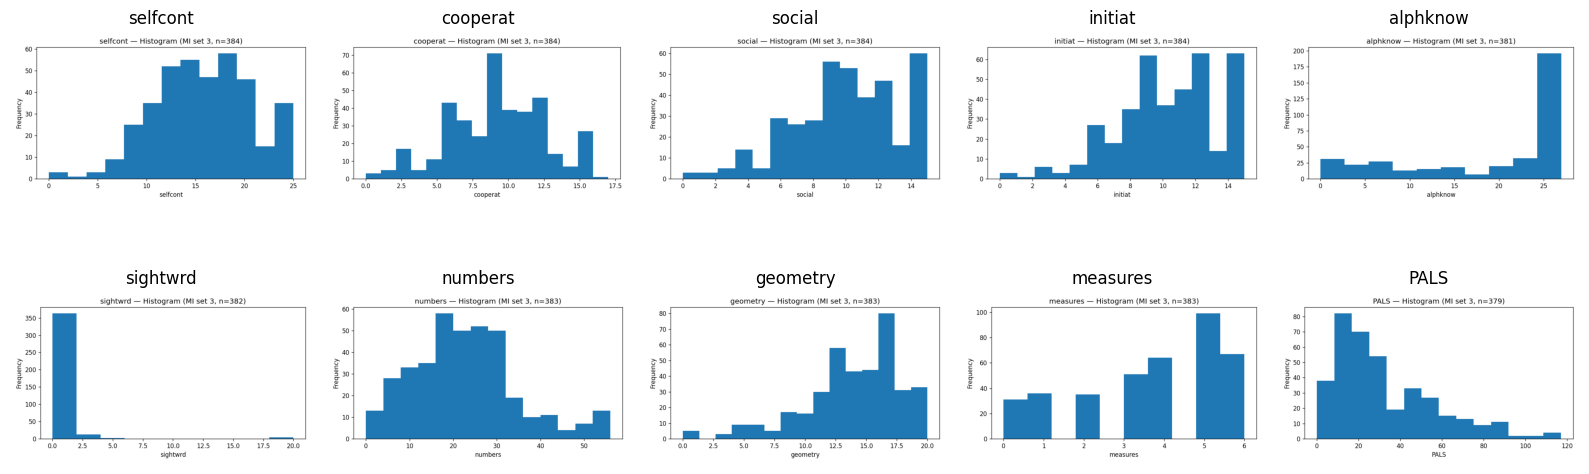

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# ------------------------------------------
# Cell 5 — Outcome histograms (per MI set + PDFs)
# ------------------------------------------
from matplotlib.backends.backend_pdf import PdfPages

# make sure PALS exists
def ensure_pals(d):
    d = d.copy()
    if 'PALS' not in d.columns:
        pals  = pd.to_numeric(d.get('pals'),  errors='coerce')
        npals = pd.to_numeric(d.get('npals'), errors='coerce')
        d['PALS'] = pals.where(pals.notna(), npals)
    return d

matched_sets = [ensure_pals(d) for d in matched_sets]

OUTCOME_COLS = [
    'selfcont','cooperat','social','initiat',
    'alphknow','sightwrd','numbers','geometry','measures','PALS'
]

os.makedirs("outcome_hists", exist_ok=True)

for k, d in enumerate(matched_sets, start=1):
    pdf_file = f"outcome_hists_MI{k}.pdf"
    with PdfPages(pdf_file) as pdf:
        for c in OUTCOME_COLS:
            x = pd.to_numeric(d.get(c), errors='coerce').dropna().values
            if x.size == 0:
                continue
            fig, ax = plt.subplots(figsize=(7,4))
            ax.hist(x, bins="auto")
            ax.set_title(f"{c} — Histogram (MI set {k}, n={len(x)})")
            ax.set_xlabel(c)
            ax.set_ylabel("Frequency")
            fig.tight_layout()
            fig.savefig(f"outcome_hists/{c}__MI{k}.png", dpi=120)
            pdf.savefig(fig)
            plt.close(fig)
    print(f"Saved: {pdf_file}")
print("All histograms saved to the 'outcome_hists' folder.")

# (If you want a single “reference” set for figures—e.g., MI,
# set 3—just run the same loop for matched_sets[2:3].)

# View a grid of histograms inline (pick an MI set)
# Show a 2x5 grid of outcome histograms for one MI set (e.g., MI set 3)
import os, math

OUTCOME_COLS = ['selfcont','cooperat','social','initiat',
                'alphknow','sightwrd','numbers','geometry','measures','PALS']

mi = 3  # change to 1..5 for other sets
fig, axes = plt.subplots(2, 5, figsize=(16,6))
axes = axes.ravel()

for ax, col in zip(axes, OUTCOME_COLS):
    png = f"outcome_hists/{col}__MI{mi}.png"
    if os.path.exists(png):
        img = plt.imread(png)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(col)
    else:
        ax.axis('off')
        ax.set_title(f"{col} (no file)")
plt.tight_layout()
plt.show()

#Preview the per-set PDF in the notebook
from IPython.display import IFrame
mi = 3  # change to 1..5
IFrame(src=f"/content/outcome_hists_MI{mi}.pdf", width=900, height=700)

# Download everything as a zip
from google.colab import files
files.download('/content/outcome_hists.zip')


In [15]:
# ------------------------------------------
# Cell 6 — Bayesian SEM (PyMC) — one MI set
# ------------------------------------------

# --- Clean imports (no Aesara) ---
!pip -q install "pymc>=5.15,<6" "arviz>=0.17" --upgrade

print("NumPy:", np.__version__)  # should be >= 2.0

# --- pick a matched dataset (e.g., MI set 3; 0-based index = 2) ---
if 'match_results' not in globals():
    raise RuntimeError("No matched data in memory. Please run the PSM cell first.")
d = match_results[2]["matched"].copy()

# --- build PALS and z-score indicators for stable priors ---
for c in ("pals","npals"): d[c] = pd.to_numeric(d.get(c), errors="coerce")
d["PALS"] = d["pals"].where(d["pals"].notna(), d["npals"])

INDICATORS = {
    "SOC": ["selfcont","cooperat","social","initiat"],
    "LIT": ["alphknow","PALS","sightwrd"],
    "MTH": ["numbers","geometry","measures"],
}
for cols in INDICATORS.values():
    for c in cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")
        mu, sd = d[c].mean(skipna=True), d[c].std(skipna=True)
        d[c] = (d[c] - mu) / sd

# --- covariates (same as outcome models) ---
covars_cat = ["program","ethnic_collapsed"]
covars_num = ["AgeM","I_to_N_ratio","educat"]
for c in covars_num:
    d[c] = pd.to_numeric(d[c], errors="coerce")

from sklearn.preprocessing import OneHotEncoder

# robust factory that works across sklearn versions
def make_ohe(drop="first"):
    try:
        # sklearn ≥1.4
        return OneHotEncoder(drop=drop, handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # sklearn ≤1.3
        return OneHotEncoder(drop=drop, handle_unknown="ignore", sparse=False)

ohe = make_ohe(drop="first")
X_cat = ohe.fit_transform(d[covars_cat].astype("category"))

# feature names API is stable in recent versions; fallback if needed
try:
    cat_names = ohe.get_feature_names_out(covars_cat).tolist()
except AttributeError:
    cat_names = ohe.get_feature_names(covars_cat).tolist()  # very old sklearn

X = np.column_stack([np.ones(len(d)),
                     d["FaInc"].astype(int).to_numpy(),
                     X_cat,
                     d[covars_num].to_numpy()])
X_names = ["Intercept","FaInc"] + cat_names + covars_num

# cluster index
match_idx, match_levels = pd.factorize(d["match_set"].astype(int))
n_match = len(match_levels)

# observed matrices (NaNs allowed)
Y_SOC = d[INDICATORS["SOC"]].to_numpy()
Y_LIT = d[INDICATORS["LIT"]].to_numpy()
Y_MTH = d[INDICATORS["MTH"]].to_numpy()

# helper to fix first loading = 1 by construction
def fixed_first_loading(name_prefix, k):
    # k indicators: first is fixed to 1, remaining free
    lam_free = pm.Normal(f"{name_prefix}_lam_free", 0.8, 0.5, dims=[f"{name_prefix}_free"])
    lam = pm.Deterministic(f"{name_prefix}_lam",
                           pt.concatenate([pt.ones((1,)), lam_free]))
    return lam

coords = {
    "obs": np.arange(len(d)),
    "x_col": X_names,
    "soc_ind": INDICATORS["SOC"],
    "lit_ind": INDICATORS["LIT"],
    "mth_ind": INDICATORS["MTH"],
    "match": match_levels,
    "SOC_free": np.arange(len(INDICATORS["SOC"])-1),
    "LIT_free": np.arange(len(INDICATORS["LIT"])-1),
    "MTH_free": np.arange(len(INDICATORS["MTH"])-1),
}

with pm.Model(coords=coords) as sem:
    # data
    X_ = pm.Data("X", X, dims=("obs","x_col"))
    match_ = pm.Data("match_idx", match_idx, dims="obs")

    # priors for structural coefficients (per latent)
    beta_soc = pm.Normal("beta_soc", 0, 1, dims=("x_col",))
    beta_lit = pm.Normal("beta_lit", 0, 1, dims=("x_col",))
    beta_mth = pm.Normal("beta_mth", 0, 1, dims=("x_col",))

    # random intercepts by matched pair for each latent
    sigma_u_soc = pm.HalfNormal("sigma_u_soc", 0.5)
    sigma_u_lit = pm.HalfNormal("sigma_u_lit", 0.5)
    sigma_u_mth = pm.HalfNormal("sigma_u_mth", 0.5)
    u_soc = pm.Normal("u_soc", 0, sigma_u_soc, dims=("match",))
    u_lit = pm.Normal("u_lit", 0, sigma_u_lit, dims=("match",))
    u_mth = pm.Normal("u_mth", 0, sigma_u_mth, dims=("match",))

    # latent scores (structural)
    eta_soc = pm.Deterministic("eta_soc", pt.dot(X_, beta_soc) + u_soc[match_], dims=("obs",))
    eta_lit = pm.Deterministic("eta_lit", pt.dot(X_, beta_lit) + u_lit[match_], dims=("obs",))
    eta_mth = pm.Deterministic("eta_mth", pt.dot(X_, beta_mth) + u_mth[match_], dims=("obs",))

    # measurement: loadings with first fixed to 1
    lam_soc = pm.Deterministic("lam_soc",
                 pt.concatenate([pt.ones((1,)),
                                 pm.Normal("SOC_lam_free", 0.8, 0.5, dims=("SOC_free",))]))
    lam_lit = pm.Deterministic("lam_lit",
                 pt.concatenate([pt.ones((1,)),
                                 pm.Normal("LIT_lam_free", 0.8, 0.5, dims=("LIT_free",))]))
    lam_mth = pm.Deterministic("lam_mth",
                 pt.concatenate([pt.ones((1,)),
                                 pm.Normal("MTH_lam_free", 0.8, 0.5, dims=("MTH_free",))]))

    sigma_soc = pm.HalfNormal("sigma_soc", 0.5, dims=("soc_ind",))
    sigma_lit = pm.HalfNormal("sigma_lit", 0.5, dims=("lit_ind",))
    sigma_mth = pm.HalfNormal("sigma_mth", 0.5, dims=("mth_ind",))

    pm.Normal("Y_SOC", mu=eta_soc[:, None] * lam_soc[None, :],
              sigma=sigma_soc, observed=Y_SOC, dims=("obs","soc_ind"))
    pm.Normal("Y_LIT", mu=eta_lit[:, None] * lam_lit[None, :],
              sigma=sigma_lit, observed=Y_LIT, dims=("obs","lit_ind"))
    pm.Normal("Y_MTH", mu=eta_mth[:, None] * lam_mth[None, :],
              sigma=sigma_mth, observed=Y_MTH, dims=("obs","mth_ind"))

    idata = pm.sample(draws=1500, tune=1500, chains=4,
                      target_accept=0.9, random_seed=2025, progressbar=True)

# quick look at FI effects (2nd column in X_names)
ix_fi = X_names.index("FaInc")
summ = az.summary(idata, var_names=["beta_soc","beta_lit","beta_mth"], hdi_prob=0.95)
print("\nPosterior (means, 95% CrI) for FI effects on latents (z-units):")
for nm in ["beta_soc","beta_lit","beta_mth"]:
    m = summ.loc[f"{nm}[{ix_fi}]", "mean"]
    l = summ.loc[f"{nm}[{ix_fi}]", "hdi_2.5%"]
    h = summ.loc[f"{nm}[{ix_fi}]", "hdi_97.5%"]
    print(f"  {nm.replace('beta_','').upper()}: {m:.3f}  [{l:.3f}, {h:.3f}]")



NumPy: 2.0.2


/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1300: ImputationWarning: Data in Y_LIT contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1300: ImputationWarning: Data in Y_MTH contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Output()


Posterior (means, 95% CrI) for FI effects on latents (z-units):


KeyError: 'beta_soc[1]'

In [17]:
# ============================
# Bayesian SEM across all 5 MI sets, pooled posterior
# ============================
import numpy as np, pandas as pd, pymc as pm, arviz as az
from pytensor import tensor as pt
from sklearn.preprocessing import OneHotEncoder

# --- parameters (tweak if needed) ---
CHAINS = 2
DRAWS  = 1000
TUNE   = 1000
TARGET_ACCEPT = 0.9
SEED   = 2025

# --- helpers ---
def make_ohe(drop="first"):
    try:
        return OneHotEncoder(drop=drop, handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop=drop, handle_unknown="ignore", sparse=False)

def ensure_ethnic_collapsed(d, col='ethnic', min_prop=0.03):
    if 'ethnic_collapsed' in d.columns:
        return d
    x = d[col].astype('category')
    vc = x.value_counts(normalize=True, dropna=False)
    keep = set(vc[vc >= min_prop].index)
    xs = x.astype(str)
    d['ethnic_collapsed'] = np.where(xs.isin([str(k) for k in keep]), xs, 'Other')
    return d

INDICATORS = {
    "SOC": ["selfcont","cooperat","social","initiat"],
    "LIT": ["alphknow","PALS","sightwrd"],
    "MTH": ["numbers","geometry","measures"],
}
covars_cat = ["program","ethnic_collapsed"]
covars_num = ["AgeM","I_to_N_ratio","educat"]

def prep_set(d, ohe):
    d = d.copy()
    # ethnic collapsed (safety)
    d = ensure_ethnic_collapsed(d)

    # PALS
    for c in ("pals","npals"):
        d[c] = pd.to_numeric(d.get(c), errors="coerce")
    d["PALS"] = d["pals"].where(d["pals"].notna(), d["npals"])

    # z-score indicators for stable priors
    for cols in INDICATORS.values():
        for c in cols:
            d[c] = pd.to_numeric(d[c], errors="coerce")
            mu, sd = d[c].mean(skipna=True), d[c].std(skipna=True)
            d[c] = (d[c] - mu) / sd

    # covariates
    for c in covars_num:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # design matrix with global OHE
    X_cat = ohe.transform(d[covars_cat].astype("category"))
    X = np.column_stack([
        np.ones(len(d)),
        d["FaInc"].astype(int).to_numpy(),
        X_cat,
        d[covars_num].to_numpy()
    ])
    # names from the global ohe
    cat_names = ohe.get_feature_names_out(covars_cat).tolist()
    X_names = ["Intercept","FaInc"] + cat_names + covars_num

    # cluster index
    match_idx, match_levels = pd.factorize(d["match_set"].astype(int))

    # observed matrices (NaNs allowed -> Bayesian FIML)
    Y_SOC = d[INDICATORS["SOC"]].to_numpy()
    Y_LIT = d[INDICATORS["LIT"]].to_numpy()
    Y_MTH = d[INDICATORS["MTH"]].to_numpy()

    return d, X, X_names, match_idx, match_levels, Y_SOC, Y_LIT, Y_MTH

def fit_bayes_sem(X, X_names, match_idx, match_levels, Y_SOC, Y_LIT, Y_MTH, seed):
    coords = {
        "obs": np.arange(len(match_idx)),
        "x_col": X_names,
        "soc_ind": INDICATORS["SOC"],
        "lit_ind": INDICATORS["LIT"],
        "mth_ind": INDICATORS["MTH"],
        "match": match_levels,
        "SOC_free": np.arange(len(INDICATORS["SOC"])-1),
        "LIT_free": np.arange(len(INDICATORS["LIT"])-1),
        "MTH_free": np.arange(len(INDICATORS["MTH"])-1),
    }

    with pm.Model(coords=coords) as sem:
        # data
        X_ = pm.Data("X", X, dims=("obs","x_col"))
        match_ = pm.Data("match_idx", match_idx, dims="obs")

        # structural betas
        beta_soc = pm.Normal("beta_soc", 0, 1, dims=("x_col",))
        beta_lit = pm.Normal("beta_lit", 0, 1, dims=("x_col",))
        beta_mth = pm.Normal("beta_mth", 0, 1, dims=("x_col",))

        # random intercepts by matched set
        sigma_u_soc = pm.HalfNormal("sigma_u_soc", 0.5)
        sigma_u_lit = pm.HalfNormal("sigma_u_lit", 0.5)
        sigma_u_mth = pm.HalfNormal("sigma_u_mth", 0.5)
        u_soc = pm.Normal("u_soc", 0, sigma_u_soc, dims=("match",))
        u_lit = pm.Normal("u_lit", 0, sigma_u_lit, dims=("match",))
        u_mth = pm.Normal("u_mth", 0, sigma_u_mth, dims=("match",))

        # latent scores (NOT stored as deterministics to keep posterior compact)
        eta_soc = pt.dot(X_, beta_soc) + u_soc[match_]
        eta_lit = pt.dot(X_, beta_lit) + u_lit[match_]
        eta_mth = pt.dot(X_, beta_mth) + u_mth[match_]

        # measurement: first loading fixed to 1
        lam_soc = pt.concatenate([pt.ones((1,)),
                                  pm.Normal("SOC_lam_free", 0.8, 0.5, dims=("SOC_free",))])
        lam_lit = pt.concatenate([pt.ones((1,)),
                                  pm.Normal("LIT_lam_free", 0.8, 0.5, dims=("LIT_free",))])
        lam_mth = pt.concatenate([pt.ones((1,)),
                                  pm.Normal("MTH_lam_free", 0.8, 0.5, dims=("MTH_free",))])

        sigma_soc = pm.HalfNormal("sigma_soc", 0.5, dims=("soc_ind",))
        sigma_lit = pm.HalfNormal("sigma_lit", 0.5, dims=("lit_ind",))
        sigma_mth = pm.HalfNormal("sigma_mth", 0.5, dims=("mth_ind",))

        pm.Normal("Y_SOC", mu=eta_soc[:, None] * lam_soc[None, :],
                  sigma=sigma_soc, observed=Y_SOC, dims=("obs","soc_ind"))
        pm.Normal("Y_LIT", mu=eta_lit[:, None] * lam_lit[None, :],
                  sigma=sigma_lit, observed=Y_LIT, dims=("obs","lit_ind"))
        pm.Normal("Y_MTH", mu=eta_mth[:, None] * lam_mth[None, :],
                  sigma=sigma_mth, observed=Y_MTH, dims=("obs","mth_ind"))

        idata = pm.sample(
            draws=DRAWS, tune=TUNE, chains=CHAINS,
            target_accept=TARGET_ACCEPT, random_seed=seed, progressbar=True
        )

    # keep only structural betas so shapes match across sets
    kept = idata.posterior[["beta_soc","beta_lit","beta_mth"]]
    return az.InferenceData(posterior=kept)

# --- 1) collect all matched sets ---
matched_sets = [res["matched"].copy() for res in match_results]

# --- 2) global OHE fit on union of categories to ensure same x_col everywhere ---
cat_union = pd.concat([ensure_ethnic_collapsed(d)[covars_cat] for d in matched_sets], ignore_index=True)
ohe_global = make_ohe(drop="first").fit(cat_union.astype("category"))
GLOBAL_X_NAMES = ["Intercept","FaInc"] + ohe_global.get_feature_names_out(covars_cat).tolist() + covars_num
print("x_col (global):", GLOBAL_X_NAMES)

# --- 3) loop over all MI sets, fit, and trim ---
idatas = []
for k, d in enumerate(matched_sets, start=1):
    d, X, X_names, match_idx, match_levels, Y_SOC, Y_LIT, Y_MTH = prep_set(d, ohe_global)
    assert X_names == GLOBAL_X_NAMES, "Per-set X_names differs from global encoder output."
    print(f"Fitting Bayesian SEM on MI set {k} (N={len(d)}) ...")
    id_k = fit_bayes_sem(X, X_names, match_idx, match_levels, Y_SOC, Y_LIT, Y_MTH, seed=SEED+k)
    idatas.append(id_k)

# --- 4) pool: concat along 'chain' (treat each set's chains as additional chains) ---
idata_all = az.concat(idatas, dim="chain")

# --- 5) extract FaInc effects (mean, 95% CrI) on SOC/LIT/MTH ---
def coef_summ(idata, varname, term, x_names):
    # select by coordinate name if present, else by position
    try:
        arr = idata.posterior[varname].sel(x_col=term)
    except Exception:
        ix = x_names.index(term)
        arr = idata.posterior[varname].isel(x_col=ix)
    mean = float(arr.mean(dim=("chain","draw")))
    hdi  = az.hdi(arr, hdi_prob=0.95)
    lo   = float(hdi.sel(hdi="lower"))
    hi   = float(hdi.sel(hdi="higher"))
    return mean, lo, hi

rows = []
for nm in ["beta_soc","beta_lit","beta_mth"]:
    m, lo, hi = coef_summ(idata_all, nm, "FaInc", GLOBAL_X_NAMES)
    rows.append({"latent": nm.replace("beta_","").upper(),
                 "term": "FaInc", "mean": m, "hdi_2.5%": lo, "hdi_97.5%": hi})
bayes_pool = pd.DataFrame(rows)
print("\nPooled Bayesian SEM — FaInc effects on latents (z-units):")
print(bayes_pool)

# Optional: save table
# bayes_pool.to_csv("bayes_sem_pooled_FaInc_effects.csv", index=False)


x_col (global): ['Intercept', 'FaInc', 'program_2', 'ethnic_collapsed_2.0', 'ethnic_collapsed_3.0', 'ethnic_collapsed_4.0', 'ethnic_collapsed_5.0', 'ethnic_collapsed_Other', 'AgeM', 'I_to_N_ratio', 'educat']
Fitting Bayesian SEM on MI set 1 (N=380) ...


/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1300: ImputationWarning: Data in Y_LIT contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1300: ImputationWarning: Data in Y_MTH contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1300: ImputationWarning: Data in Y_LIT contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Fitting Bayesian SEM on MI set 2 (N=382) ...


...

Fitting Bayesian SEM on MI set 5 (N=380) ...


/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1300: ImputationWarning: Data in Y_MTH contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


TypeError: float() argument must be a string or a real number, not 'Dataset'

In [18]:
# Robust HDI + pooled table & diagnostic
import arviz as az
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- helpers ----
def hdi_bounds(arr_or_ds, varname=None, prob=0.95):
    """
    Return (lower, upper) floats for HDI of a DataArray or Dataset.
    If Dataset, provide varname or it will use the first data var.
    """
    h = az.hdi(arr_or_ds, hdi_prob=prob)
    if isinstance(h, xr.Dataset):
        if varname is None:
            varname = list(h.data_vars)[0]
        da = h[varname]
    else:
        da = h
    lo = float(da.sel(hdi="lower").values)
    hi = float(da.sel(hdi="higher").values)
    return lo, hi

def coef_summ(idata, varname, term, x_names):
    """
    Mean and 95% HDI for a coefficient named `term` along x_col in `varname`.
    Works regardless of ArviZ/xarray return types.
    """
    da = idata.posterior[varname]
    # select by label if possible, else by position
    try:
        da = da.sel(x_col=term)
    except Exception:
        ix = x_names.index(term)
        da = da.isel(x_col=ix)
    mean = float(da.mean(dim=("chain","draw")).values)
    lo, hi = hdi_bounds(da, prob=0.95)
    return mean, lo, hi, da  # also return DA for diagnostics

rows = []
diag_rows = []
for nm in ["beta_soc","beta_lit","beta_mth"]:
    mean, lo, hi, da = coef_summ(idata_all, nm, "FaInc", GLOBAL_X_NAMES)
    rows.append({
        "latent": nm.replace("beta_","").upper(),
        "term": "FaInc",
        "mean": mean,
        "hdi_2.5%": lo,
        "hdi_97.5%": hi
    })
    summ = az.summary(da, hdi_prob=0.95)  # diagnostics for this coefficient only
    diag_rows.append({
        "latent": nm.replace("beta_","").upper(),
        "rhat": float(summ["r_hat"].iloc[0]),
        "ess_bulk": float(summ["ess_bulk"].iloc[0]),
        "ess_tail": float(summ["ess_tail"].iloc[0])
    })

bayes_pool = pd.DataFrame(rows)
bayes_diag = pd.DataFrame(diag_rows)

print("\nPooled Bayesian SEM — FaInc effects on latents (z-units):")
print(bayes_pool)
print("\nDiagnostics for FaInc rows (pooled):")
print(bayes_diag)

# Optional: save
# bayes_pool.to_csv("bayes_sem_pooled_FaInc_effects.csv", index=False)
# bayes_diag.to_csv("bayes_sem_pooled_FaInc_diagnostics.csv", index=False)



Pooled Bayesian SEM — FaInc effects on latents (z-units):
  latent   term      mean  hdi_2.5%  hdi_97.5%
0    SOC  FaInc  0.070465 -0.012746   0.150759
1    LIT  FaInc -0.062141 -0.184558   0.054660
2    MTH  FaInc  0.044442 -0.056206   0.145382

Diagnostics for FaInc rows (pooled):
  latent  rhat  ess_bulk  ess_tail
0    SOC  1.04     143.0    5801.0
1    LIT  1.03     270.0    4580.0
2    MTH  1.01     669.0    6894.0


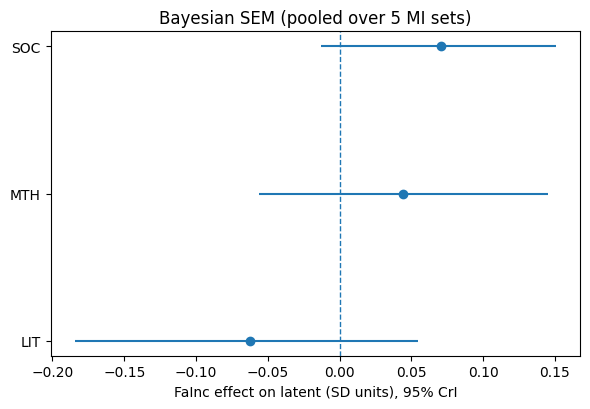

In [19]:
# Forest plot of pooled Bayesian effects
df = bayes_pool.sort_values("latent")
y = np.arange(len(df))

plt.figure(figsize=(6,4.2))
plt.hlines(y, df["hdi_2.5%"], df["hdi_97.5%"])
plt.plot(df["mean"], y, "o")
plt.axvline(0, ls="--", lw=1)
plt.yticks(y, df["latent"])
plt.xlabel("FaInc effect on latent (SD units), 95% CrI")
plt.title("Bayesian SEM (pooled over 5 MI sets)")
plt.tight_layout()
plt.savefig("bayes_sem_forest.png", dpi=200)
plt.show()
